# Random-feature double descent: expanded follow-up

**Prepared, unexecuted follow-up (protocol 1.1).** Use 1,024 training / 4,096 validation / 32,768 test examples, ten feature seeds and 21 capacities up to 8,192. The matrix contains 210 decompositions and 840 primary predictors. Only linear output coefficients are fitted; there are no epochs.

The original study was completed previously; the owner removed its local run for a fresh start. This notebook uses fresh input/noise seeds and a fresh numbered run. Results from different runs must not be pooled or treated as an isolated sample-size comparison: both sample size and data realization change.

Run one conceptual action per cell. CPU float64, four compute threads and the 30-minute active-time budget remain fixed. The budget is a stop rule, not a measured completion guarantee. Read `docs/expanded-protocol.md` and `docs/reproduce.md` before execution.


## Imports and checkout discovery

Start Jupyter inside this checkout. No personal absolute path is required.

In [1]:
import sys
from pathlib import Path

In [2]:
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (candidate / "src" / "config.py").is_file()
        and (candidate / "requirements.txt").is_file()
        and (candidate / "notebooks" / "random_feature_double_descent.ipynb").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Start Jupyter from the random-feature-double-descent checkout.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT

PosixPath('/Users/biitu/Documents/Growth/labs/random-feature-double-descent')

In [3]:
import pandas as pd

from src.analysis import (
    aggregate_results,
    inspect_development,
    plot_conditioning_and_coefficients,
    plot_cutoff_sensitivity,
    plot_error_curves,
    plot_noise_differences,
    plot_rank_and_interpolation,
    plot_runtime_and_status,
    plot_singular_spectra,
    plot_solver_comparison,
)
from src.checkpoints import load_regressor
from src.config import DataConfig, ExecutionConfig, ExperimentConfig, FeatureConfig, SolverConfig
from src.data import prepare_data, prepare_test_data
from src.evaluate import evaluate_checkpoints, freeze_evaluation
from src.fit import fit_sweep, run_preflight
from src.reporting import generate_report
from src.runs import create_run, inspect_environment, resume_run, summarize_run
from src.runtime import validate_runtime

## Editable registered configuration

The larger matrix below is fixed before seeing its results. Change configuration only before creating a fresh run. Ten feature seeds vary the Fourier features while preserving one fixed dataset/noise realization. They do not provide uncertainty across datasets.


In [4]:
data_config = DataConfig(
    input_dim=8,
    train_size=1024,
    validation_size=4096,
    test_size=32768,
    input_seeds=(31001, 31002, 31003),
    noise_seeds=(32001, 32002, 32003),
    noise_stds=(0.0, 0.3),
)

In [5]:
feature_config = FeatureConfig(
    counts=(
        64,
        128,
        256,
        384,
        512,
        768,
        896,
        960,
        992,
        1023,
        1024,
        1025,
        1056,
        1088,
        1152,
        1280,
        1536,
        2048,
        3072,
        4096,
        8192,
    ),
    seeds=(2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035),
    phase_seed_offset=10000,
    lengthscale=8.0**0.5,
)

In [6]:
solver_config = SolverConfig(
    rcond=1e-12,
    ridge_lambda=1e-4,
    interpolation_tolerance=1e-8,
    sensitivity_rconds=(1e-10, 1e-14),
)

In [7]:
execution_config = ExecutionConfig(
    threads=4,
    eval_batch_size=1024,
    budget_seconds=1800.0,
    preflight_widths=(256, 1024, 8192),
)

In [8]:
config = ExperimentConfig(
    data=data_config,
    features=feature_config,
    solver=solver_config,
    execution=execution_config,
    protocol_version="1.1",
)

## Create or resume the expanded run

Keep `RUN_NAME = None` to allocate a fresh numbered directory, normally `run_001` after cleanup. After the run exists, record its actual name and use that name for explicit resume with unchanged configuration. Do not resume an original-study backup using these larger settings; run names alone do not identify a scientific protocol. Rerunning the fresh-run cell allocates another directory; later cells reuse `run`.


In [9]:
RUN_NAME = None

In [10]:
run = (
    create_run(PROJECT_ROOT, config)
    if RUN_NAME is None
    else resume_run(PROJECT_ROOT, RUN_NAME, config=config)
)

In [11]:
inspect_environment(run)

{'environment': {'default_device': 'cpu',
  'default_dtype': 'torch.float32',
  'device': 'cpu',
  'dtype': 'float64',
  'executable': '/Users/biitu/Documents/Growth/labs/random-feature-double-descent/.venv/bin/python',
  'interop_threads': 10,
  'machine': 'arm64',
  'packages': {'absl-py': '2.5.0',
   'anyio': '4.15.1',
   'appnope': '1.0.0',
   'argon2-cffi': '25.1.0',
   'argon2-cffi-bindings': '26.1.0',
   'arrow': '1.4.0',
   'asttokens': '3.0.2',
   'async-lru': '2.3.0',
   'attrs': '26.1.0',
   'babel': '2.18.0',
   'beautifulsoup4': '4.15.0',
   'bleach': '6.4.0',
   'certifi': '2026.7.22',
   'cffi': '2.1.1',
   'charset-normalizer': '3.5.1',
   'comm': '0.2.3',
   'contourpy': '1.4.0',
   'cycler': '0.12.1',
   'debugpy': '1.8.22',
   'defusedxml': '0.7.1',
   'executing': '2.2.1',
   'fastjsonschema': '2.22.2',
   'filelock': '4.0.4',
   'fonttools': '4.66.0',
   'fqdn': '1.5.1',
   'fsspec': '2026.9.0',
   'grpcio': '1.84.0',
   'h11': '0.16.0',
   'httpcore': '1.0.9',
   

## Development data

Only training and validation arrays are generated here. Both noise conditions use the same underlying inputs, teacher values and noise realization. Test arrays are unavailable until fitting is frozen.

In [12]:
data = prepare_data(run)

In [13]:
pd.DataFrame(
    [
        {
            "partition": partition.name,
            "samples": len(partition.x),
            "input_dim": partition.x.shape[1],
            "label_conditions": partition.labels.shape[1],
        }
        for partition in (data.train, data.validation)
    ]
)

,partition,samples,input_dim,label_conditions
0,train,1024,8,2
1,validation,4096,8,2


In [14]:
pd.DataFrame(
    {
        "x1": data.train.x[:12, 0].tolist(),
        "x2": data.train.x[:12, 1].tolist(),
        "x3": data.train.x[:12, 2].tolist(),
        "clean_target": data.train.clean[:12].tolist(),
        "noise": data.train.noise[:12].tolist(),
        "observed_sigma_0.3": data.train.labels[:12, -1].tolist(),
    }
)

,x1,x2,x3,clean_target,noise,observed_sigma_0.3
0,0.990597,-0.106084,0.746760,1.265429,-0.241957,1.192842
1,1.525322,0.253457,0.250510,1.574861,-0.436989,1.443764
2,-0.829172,-1.138493,-1.214449,-1.892605,0.677730,-1.689286
3,0.676312,0.243302,0.048941,1.007065,0.443130,1.140004
4,-0.071180,1.481110,1.484790,0.897333,-1.223214,0.530369
5,0.690682,-0.138843,-0.987721,0.476808,-0.719802,0.260867
6,-0.896336,-0.086184,0.754062,-0.866780,-1.776452,-1.399716
7,-1.366078,-1.299886,0.240006,-1.860461,0.765146,-1.630917
8,-1.004767,1.240103,-1.195602,-0.801474,-1.431552,-1.230940
9,1.479553,0.638357,-1.248273,1.402750,-1.342062,1.000132


In [15]:
pd.DataFrame(
    {
        "features": config.features.counts,
        "feature_sample_ratio": [p / config.data.train_size for p in config.features.counts],
        "training_matrix_MiB": [
            config.data.train_size * p * 8 / 2**20 for p in config.features.counts
        ],
    }
)

,features,feature_sample_ratio,training_matrix_MiB
0,64,0.062500,0.500000
1,128,0.125000,1.000000
2,256,0.250000,2.000000
3,384,0.375000,3.000000
4,512,0.500000,4.000000
5,768,0.750000,6.000000
6,896,0.875000,7.000000
7,960,0.937500,7.500000
8,992,0.968750,7.750000
9,1023,0.999023,7.992188


## Explicit correctness and timing gates

The next cell executes correctness checks when you run it; no checks or experiments were executed while preparing this follow-up. The preflight then measures capacities 256, 1,024 and 8,192 for the first seed. Those completed registered fits are reused by the sweep.

A conservative approximate projection above the 30-minute budget blocks the sweep. Actual expanded runtime has not been measured. The largest training feature matrix and evaluation chunk are each 64 MiB, excluding other arrays and solver workspace; this is not a peak-memory measurement.


In [16]:
runtime_checks = validate_runtime(run)

In [17]:
preflight = run_preflight(run, data)
preflight

Preflight decompositions:   0%|          | 0/3 [00:00<?, ?it/s]

{'allowed': True,
 'reason': 'Timing is approximate; upper-width buckets, a 2x multiplier and a 120s preparation/report reserve are used.',
 'fit_seconds_before_safety_factor': 166.96642996700461,
 'evaluation_seconds_before_safety_factor': 168.72299955000472,
 'reserve_seconds': 120.0,
 'safety_multiplier': 2.0,
 'projected_remaining_seconds': 791.3788590340187,
 'projected_total_seconds': 801.3852943680188,
 'budget': {'active': {'label': 'preflight_projection',
   'pid': 7850,
   'started_at': '2026-09-28T05:10:40.777279+00:00'},
  'extensions': [],
  'limit_seconds': 1800.0,
  'used_seconds': 10.006435334000116,
  'remaining_seconds': 1789.9935646659999},
 'samples': [{'config_hash': '9ee59ec9d385edc57c2b215599f0adcce0ff3871e593847360c37e1631e645db',
   'cpu_rss_bytes': 306298880,
   'development_identity': 'e2f31971c458a60fd6c29e8eca1393f792a53a1f190d080569f71d4b4eb23559',
   'failure_reason': None,
   'feature_seconds': 0.007933249999950931,
   'n_features': 256,
   'prediction_s

## Fit the registered sweep

Each unit commits one SVD and all associated predictors atomically. Numerical failures remain explicit. Infrastructure errors stop execution. No automatic grid or precision changes occur. Budget checks happen between units; a running operation can finish past the limit.

If an intentional budget extension is needed after inspecting the receipts, import `extend_budget` from `src.runs`, then use `extend_budget(run, extra_seconds=..., reason=...)` in a new explicit decision cell. No extension is performed by this notebook automatically.

In [18]:
fit_status = fit_sweep(run, data)

Registered decompositions:   0%|          | 0/210 [00:00<?, ?it/s]

In [19]:
pd.DataFrame(summarize_run(run))

,seed,n_features,config_hash,cpu_rss_bytes,development_identity,failure_reason,feature_seconds,prediction_seconds,status,svd_count,svd_seconds,total_seconds
0,2026,64,9ee59ec9d385edc57c2b215599f0adcce0ff3871e59384...,698138624,e2f31971c458a60fd6c29e8eca1393f792a53a1f190d08...,None,0.006609,0.000784,complete,1,0.002541,0.015675
1,2026,128,9ee59ec9d385edc57c2b215599f0adcce0ff3871e59384...,698155008,e2f31971c458a60fd6c29e8eca1393f792a53a1f190d08...,None,0.004914,0.001168,complete,1,0.006730,0.018329
2,2026,256,9ee59ec9d385edc57c2b215599f0adcce0ff3871e59384...,306298880,e2f31971c458a60fd6c29e8eca1393f792a53a1f190d08...,None,0.007933,0.002564,complete,1,0.026420,0.043743
3,2026,384,9ee59ec9d385edc57c2b215599f0adcce0ff3871e59384...,714063872,e2f31971c458a60fd6c29e8eca1393f792a53a1f190d08...,None,0.006709,0.003526,complete,1,0.029608,0.046799
4,2026,512,9ee59ec9d385edc57c2b215599f0adcce0ff3871e59384...,735117312,e2f31971c458a60fd6c29e8eca1393f792a53a1f190d08...,None,0.006211,0.004618,complete,1,0.051323,0.068918
...,...,...,...,...,...,...,...,...,...,...,...,...
205,2035,1536,9ee59ec9d385edc57c2b215599f0adcce0ff3871e59384...,1147158528,e2f31971c458a60fd6c29e8eca1393f792a53a1f190d08...,None,0.008178,0.011930,complete,1,0.270096,0.301757
206,2035,2048,9ee59ec9d385edc57c2b215599f0adcce0ff3871e59384...,994361344,e2f31971c458a60fd6c29e8eca1393f792a53a1f190d08...,None,0.009428,0.019180,complete,1,0.346339,0.388497
207,2035,3072,9ee59ec9d385edc57c2b215599f0adcce0ff3871e59384...,994361344,e2f31971c458a60fd6c29e8eca1393f792a53a1f190d08...,None,0.010493,0.020338,complete,1,0.514627,0.563319
208,2035,4096,9ee59ec9d385edc57c2b215599f0adcce0ff3871e59384...,1027915776,e2f31971c458a60fd6c29e8eca1393f792a53a1f190d08...,None,0.011986,0.029309,complete,1,0.677589,0.744829


In [20]:
inspect_development(run)

,coefficient_norm,condition_number,condition_number_is_infinite,cpu_rss_bytes,feature_seconds,interpolates,n_features,noise_index,noise_std,numerical_rank,...,train_count,train_observed_mse,train_observed_sse,train_signal_mse,train_signal_sse,validation_count,validation_observed_mse,validation_observed_sse,validation_signal_mse,validation_signal_sse
0,7.496940,60.746223,False,698138624,0.006609,False,64,0,0.0,64,...,1024,7.978803e-02,8.170294e+01,7.978803e-02,8.170294e+01,4096,0.095431,390.887039,0.095431,390.887039
1,7.360209,60.746223,False,698138624,0.006609,False,64,1,0.3,64,...,1024,1.586773e-01,1.624855e+02,8.657538e-02,8.865319e+01,4096,0.189578,776.512173,0.098787,404.630772
2,6.684657,60.746223,False,698138624,0.006609,False,64,0,0.0,64,...,1024,8.028386e-02,8.221067e+01,8.028386e-02,8.221067e+01,4096,0.094469,386.943514,0.094469,386.943514
3,6.580190,60.746223,False,698138624,0.006609,False,64,1,0.3,64,...,1024,1.591439e-01,1.629633e+02,8.664926e-02,8.872885e+01,4096,0.188510,772.138603,0.097872,400.883743
4,19.084024,157.087395,False,698155008,0.004914,False,128,0,0.0,128,...,1024,3.931026e-02,4.025370e+01,3.931026e-02,4.025370e+01,4096,0.073543,301.231714,0.073543,301.231714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,14.583227,25787.153290,False,1027915776,0.011986,False,4096,1,0.3,1024,...,1024,6.143812e-02,6.291263e+01,1.854239e-02,1.898741e+01,4096,0.121340,497.008517,0.030478,124.839266
836,26.870263,18578.266222,False,1095057408,0.019240,True,8192,0,0.0,1024,...,1024,1.422453e-28,1.456592e-25,1.422453e-28,1.456592e-25,4096,0.002285,9.361348,0.002285,9.361348
837,1002.404367,18578.266222,False,1095057408,0.019240,True,8192,1,0.3,1024,...,1024,3.208269e-27,3.285267e-24,8.129338e-02,8.324442e+01,4096,5.689778,23305.329205,5.599179,22934.236881
838,12.283659,18578.266222,False,1095057408,0.019240,False,8192,0,0.0,1024,...,1024,4.440195e-03,4.546760e+00,4.440195e-03,4.546760e+00,4096,0.014639,59.962110,0.014639,59.962110


## Freeze and evaluate

Freeze every registered fitted-model identity before generating test arrays. Validation is diagnostic; there is no model or hyperparameter selection. Incomplete sweeps cannot proceed. The primary metric is test MSE against the clean teacher function. Observed-label MSE and baselines are retained separately.

In [21]:
frozen = freeze_evaluation(run)

In [22]:
test_data = prepare_test_data(run)

In [23]:
evaluation = evaluate_checkpoints(run, test_data)

Frozen model evaluation:   0%|          | 0/210 [00:00<?, ?it/s]

In [24]:
tables = aggregate_results(run)

## Separate figures

Each cell saves its own PNG and SVG, then displays the figure. Thin lines show feature seeds; thick lines show means; shaded bands show sample SD. Contributing counts are visible. The seed variation is conditional on one fixed dataset/noise realization, not an uncertainty interval over datasets. Symmetric-log axes retain exact zeros, extreme values and negative paired differences.

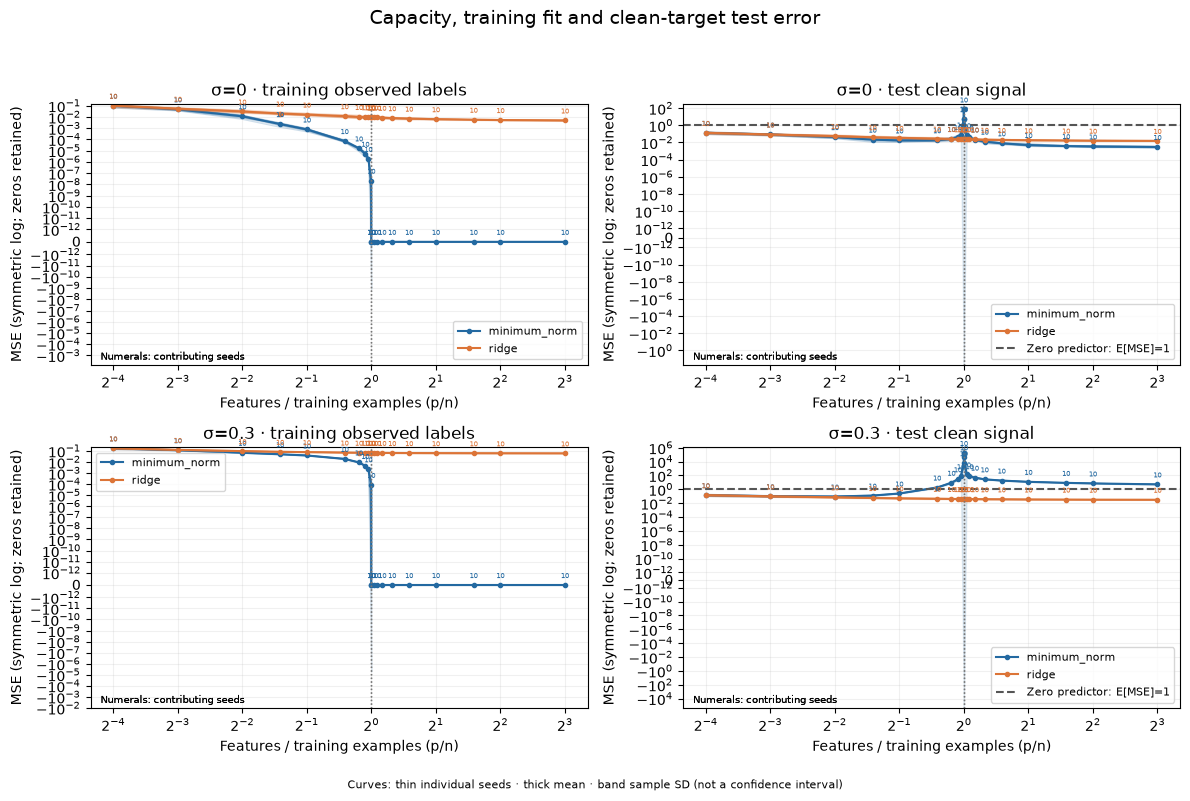

In [25]:
plot_error_curves(run)

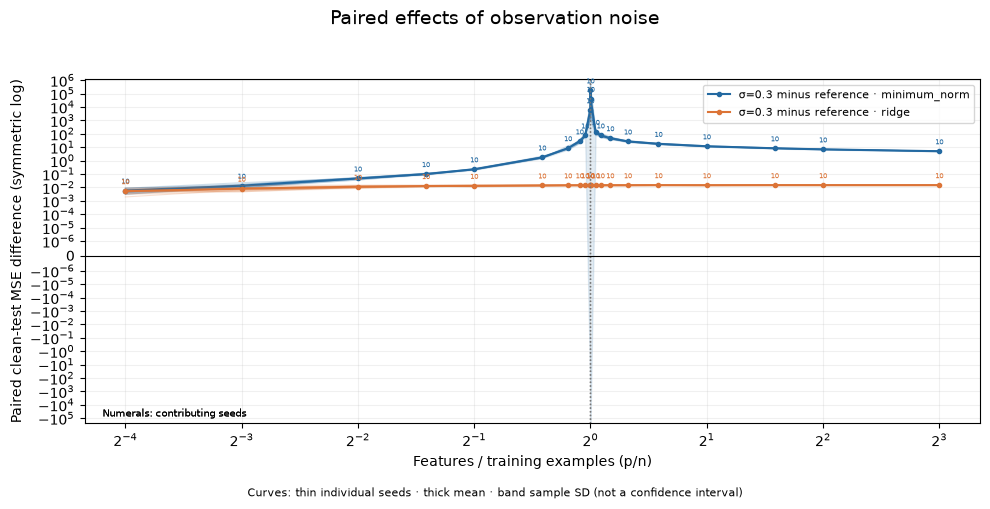

In [26]:
plot_noise_differences(run)

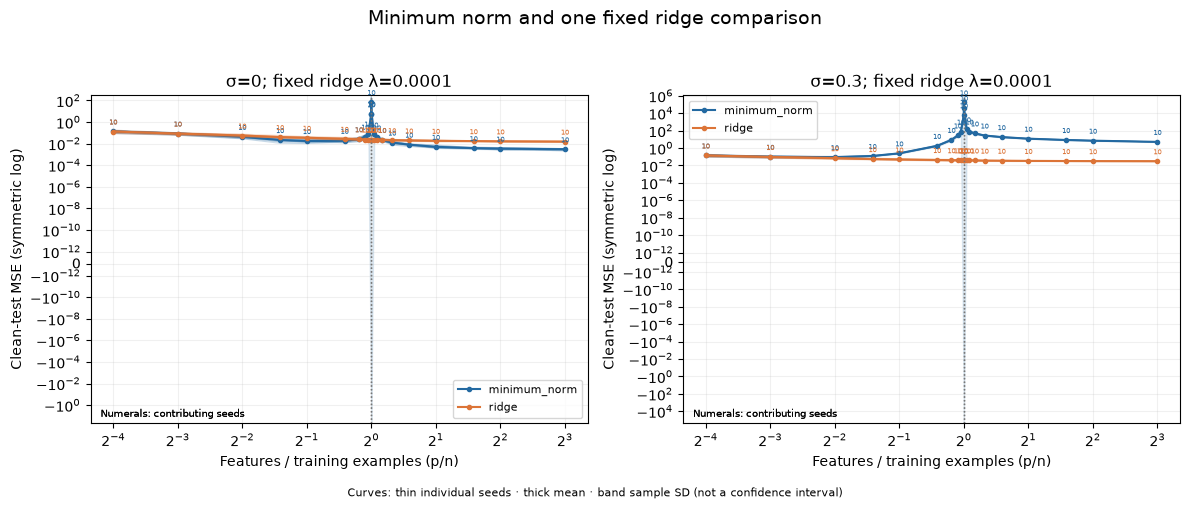

In [27]:
plot_solver_comparison(run)

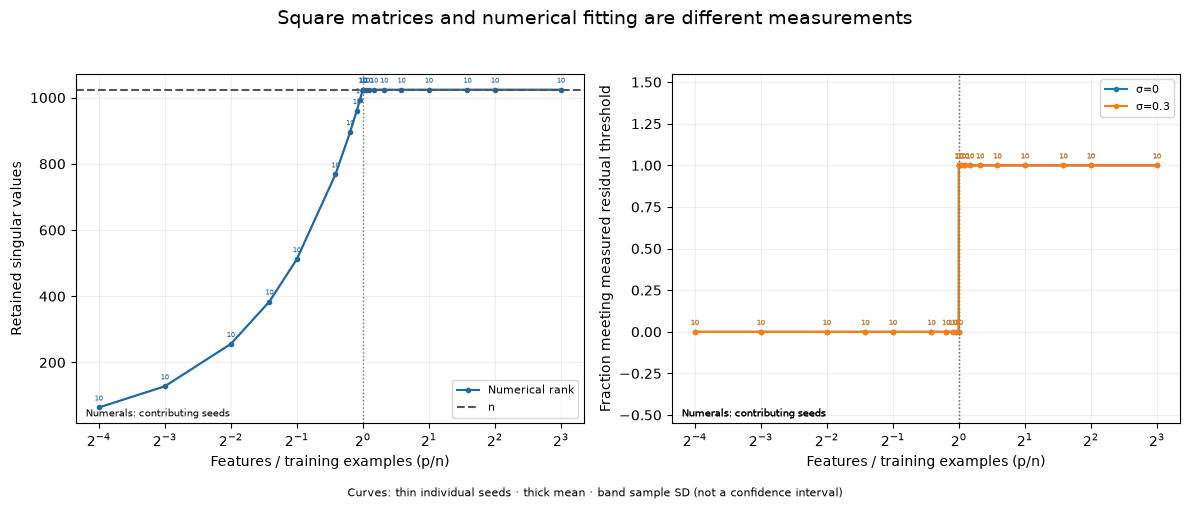

In [28]:
plot_rank_and_interpolation(run)

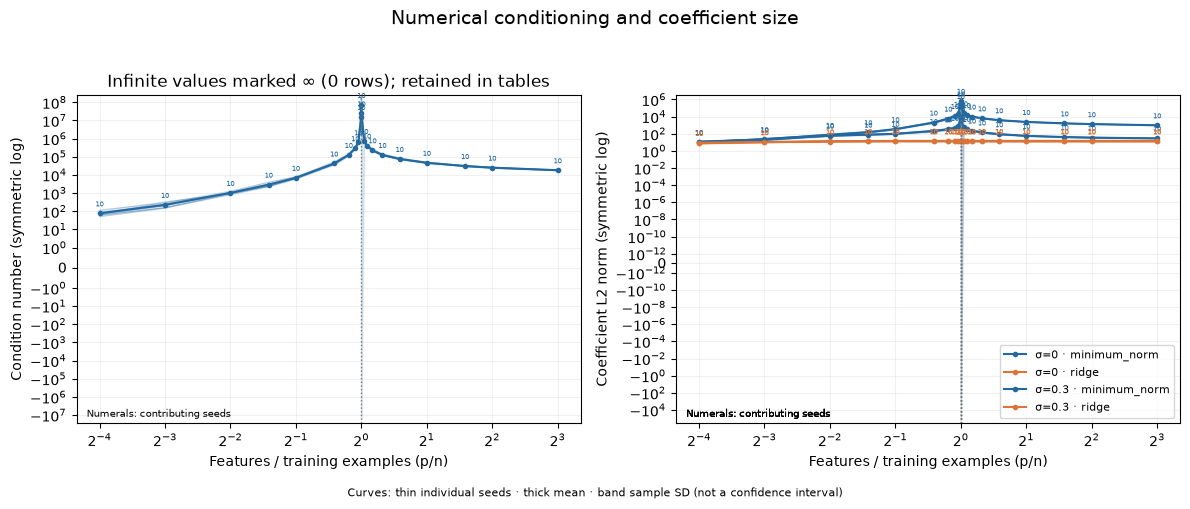

In [29]:
plot_conditioning_and_coefficients(run)

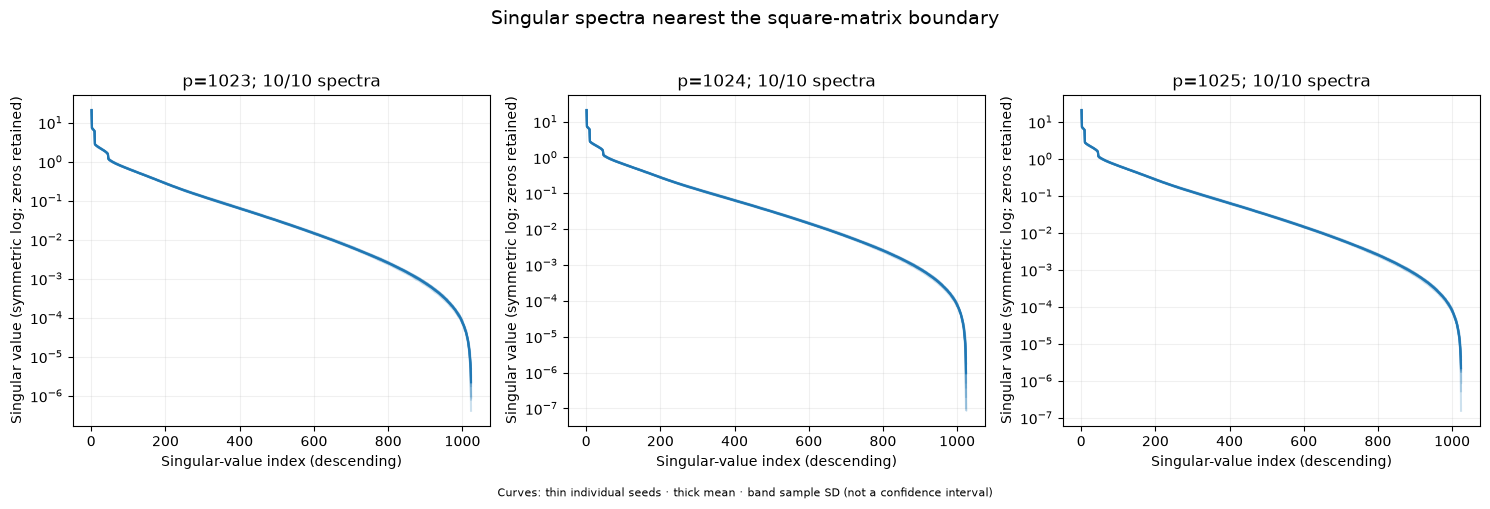

In [30]:
plot_singular_spectra(run)

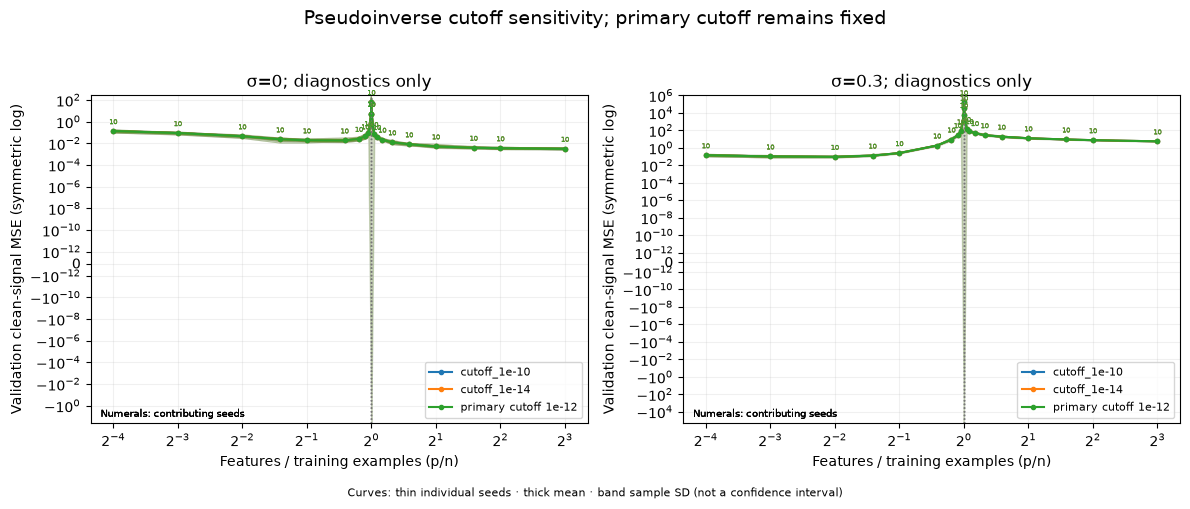

In [31]:
plot_cutoff_sensitivity(run)

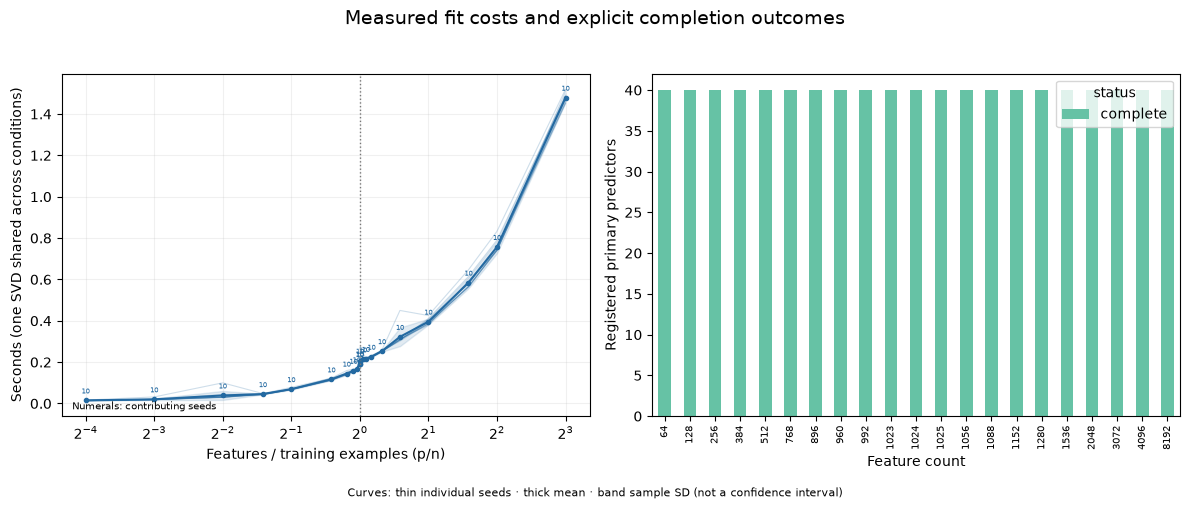

In [32]:
plot_runtime_and_status(run)

## Technical report

The report reads saved results and links every figure and table. It distinguishes measurements, interpretations and limitations; it never declares double descent proven automatically.

In [33]:
report_path = generate_report(run)
report_path

PosixPath('/Users/biitu/Documents/Growth/labs/random-feature-double-descent/runs/run_001/report/technical_report.md')

## Standalone loading

This fixed example loads the first feature seed, capacity 1,024 and the noisy minimum-norm predictor. It requires that registered predictor to have completed successfully; select an explicitly identified successful artifact if it failed. Frequencies, phases and coefficients are self-contained; loading does not require the dataset.


In [34]:
predictor = load_regressor(run, seed=2026, count=1024, noise_std=0.3, solver="minimum_norm")

In [35]:
predictor.predict(data.validation.x[:5])

tensor([  26.2573, -295.2579,  -84.7286, -348.4174, -159.9155],
       dtype=torch.float64)

## Optional TensorBoard

Run this separate cell only when you want the local dashboard. It launches no fitting. Logs also remain available in CSV/JSONL. Stop the dashboard when it is no longer needed.

In [36]:
from tensorboard import notebook as tensorboard_notebook

tensorboard_notebook.start(f'--logdir "{run.path / "tensorboard"}"')